<a href="https://colab.research.google.com/github/BU-Spark/ds-ciss-predictive-homlessness/blob/data-cleaning-feature/Data_Engineering_stats_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Anisha_Final_Dataset.csv to Anisha_Final_Dataset.csv


In [ ]:
import pandas as pd
df = pd.read_csv('Anisha_Final_Dataset.csv')

df.head()

,Total Population,Median Gross Rent,Median Household Income,Poverty_Rate,Vacancy_Rate,Renter_Household_Rate,Cost_Burdened_Rate,Unemployment_Rate,"Total Year-Round Beds (ES, TH, SH)",Average Temperature,Overall Homeless,Overall Homeless Individuals,Overall Homeless People in Families,Unsheltered Homeless,Sheltered Total Homeless,Overall_Homeless_Per_Capita,Overall_Homeless_Individuals_Per_Capita,Overall_Homeless_People_in_Families_Per_Capita,Unsheltered_Homeless_Per_Capita,Sheltered_Homeless_Per_Capita
0,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,5.5,974.0,696.0,278.0,132.0,842.0,0.003781,0.002702,0.001079,0.000512,0.003268
1,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,0.4,1023.0,695.0,328.0,102.0,921.0,0.003971,0.002698,0.001273,0.000396,0.003575
2,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,-0.2,1267.0,821.0,446.0,157.0,1110.0,0.004918,0.003187,0.001731,0.000609,0.004308
3,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,1.5,1231.0,740.0,491.0,118.0,1113.0,0.004778,0.002872,0.001906,0.000458,0.004320
4,250934,54926,3573107,8.504627,7.073878,42.293547,42.845948,7.593841,NaN,7.0,1223.0,794.0,429.0,141.0,1082.0,0.004874,0.003164,0.001710,0.000562,0.004312


In [ ]:
print(df.columns)


Index(['Total Population', 'Median Gross Rent', 'Median Household Income',
       'Poverty_Rate', 'Vacancy_Rate', 'Renter_Household_Rate',
       'Cost_Burdened_Rate', 'Unemployment_Rate',
       'Total Year-Round Beds (ES, TH, SH)', 'Average Temperature',
       'Overall Homeless', 'Overall Homeless Individuals',
       'Overall Homeless People in Families', 'Unsheltered Homeless',
       'Sheltered Total Homeless', 'Overall_Homeless_Per_Capita',
       'Overall_Homeless_Individuals_Per_Capita',
       'Overall_Homeless_People_in_Families_Per_Capita',
       'Unsheltered_Homeless_Per_Capita', 'Sheltered_Homeless_Per_Capita'],
      dtype='object')


In [ ]:
df['Poverty_Unemployment_Interaction'] = df['Poverty_Rate'] * df['Unemployment_Rate']


In [ ]:
df['Rent Burden'] = df['Median Gross Rent'] / df['Median Household Income']

In [ ]:
df['Vacancy_Renter_Interaction'] = df['Vacancy_Rate'] * df['Renter_Household_Rate']


In [ ]:
df['Avg_Temperature_Spring'] = None
df['Avg_Temperature_Summer'] = None
df['Avg_Temperature_Fall'] = None
df['Avg_Temperature_Winter'] = None


In [ ]:
print(df.shape[0])


6524


In [ ]:
df.head()

,Total Population,Median Gross Rent,Median Household Income,Poverty_Rate,Vacancy_Rate,Renter_Household_Rate,Cost_Burdened_Rate,Unemployment_Rate,"Total Year-Round Beds (ES, TH, SH)",Average Temperature,...,Unsheltered Homeless,Sheltered Total Homeless,Overall_Homeless_Per_Capita,Overall_Homeless_Individuals_Per_Capita,Overall_Homeless_People_in_Families_Per_Capita,Unsheltered_Homeless_Per_Capita,Sheltered_Homeless_Per_Capita,Poverty_Unemployment_Interaction,Rent Burden,Vacancy_Renter_Interaction
0,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,5.5,...,132.0,842.0,0.003781,0.002702,0.001079,0.000512,0.003268,62.928590,0.015128,303.379741
1,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,0.4,...,102.0,921.0,0.003971,0.002698,0.001273,0.000396,0.003575,62.928590,0.015128,303.379741
2,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,-0.2,...,157.0,1110.0,0.004918,0.003187,0.001731,0.000609,0.004308,62.928590,0.015128,303.379741
3,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,1.5,...,118.0,1113.0,0.004778,0.002872,0.001906,0.000458,0.004320,62.928590,0.015128,303.379741
4,250934,54926,3573107,8.504627,7.073878,42.293547,42.845948,7.593841,NaN,7.0,...,141.0,1082.0,0.004874,0.003164,0.001710,0.000562,0.004312,64.582783,0.015372,299.179402


In [ ]:
features = [
    'Total Population',
    'Median Gross Rent',
    'Median Household Income',
    'Poverty_Rate',
    'Vacancy_Rate',
    'Unemployment_Rate',
    'Cost_Burdened_Rate',
    'Renter_Household_Rate',
    'Total Year-Round Beds (ES, TH, SH)',
    'Average Temperature'
]

In [ ]:
import numpy as np

statistics = {}
pd.set_option('display.float_format', '{:,.2f}'.format)

for feature in features:
    statistics[feature] = {
        'Mean': np.mean(df[feature]),
        'Median': np.median(df[feature]),
        'Min': np.min(df[feature]),
        'Max': np.max(df[feature]),
        'IQR': np.percentile(df[feature], 75) - np.percentile(df[feature], 25)
    }

stats_df = pd.DataFrame(statistics).T

print(stats_df.to_string())

                                            Mean       Median        Min            Max          IQR
Total Population                      776,706.37   465,644.00  24,774.00  10,529,853.00   580,185.25
Median Gross Rent                     186,384.24   105,198.00   8,167.00   3,675,419.00   150,856.50
Median Household Income            10,829,048.72 6,332,756.50 428,824.00 166,373,824.00 8,713,550.50
Poverty_Rate                               14.02        13.72       3.64          48.07         5.67
Vacancy_Rate                               12.51        10.97       3.78          50.34         7.54
Unemployment_Rate                           7.65         7.27       2.41          28.59         3.54
Cost_Burdened_Rate                         46.70        46.56      27.17          63.70         6.80
Renter_Household_Rate                      35.04        33.28      15.89          69.22        11.31
Total Year-Round Beds (ES, TH, SH)      1,072.98          NaN       0.00      91,411.00    

In [ ]:
stats_df.to_csv('slides.csv', index=False)

In [ ]:

pd.set_option('display.float_format', '{:,.2f}'.format)

target_features = [
    'Overall Homeless',
    'Overall Homeless Individuals',
    'Overall Homeless People in Families',
    'Unsheltered Homeless',
    'Sheltered Total Homeless'
]

target_statistics = {}

for feature in target_features:
    target_statistics[feature] = {
        'Mean': np.mean(df[feature]),
        'Median': np.median(df[feature]),
        'Min': np.min(df[feature]),
        'Max': np.max(df[feature]),
        'IQR': np.percentile(df[feature], 75) - np.percentile(df[feature], 25)
    }

target_stats_df = pd.DataFrame(target_statistics).T

target_stats_df = target_stats_df.round(2)

print(target_stats_df)


                                        Mean  Median   Min        Max  IQR
Overall Homeless                    3,103.45     NaN 10.00 653,104.00  NaN
Overall Homeless Individuals        2,024.25     NaN  0.00 467,020.00  NaN
Overall Homeless People in Families 1,077.12     NaN  0.00 241,937.00  NaN
Unsheltered Homeless                1,096.79     NaN  0.00 256,610.00  NaN
Sheltered Total Homeless            2,006.66     NaN  0.00 403,543.00  NaN


In [ ]:
target_stats_df.to_csv('slides2.csv', index=False)

In [ ]:
pip install pandas numpy scikit-learn matplotlib


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:

df_clean = df.dropna()

x = df_clean[['Total Population',
    'Median Gross Rent',
    'Median Household Income',
    'Poverty_Rate',
    'Vacancy_Rate',
    'Unemployment_Rate',
    'Cost_Burdened_Rate',
    'Renter_Household_Rate',
    'Total Year-Round Beds (ES, TH, SH)',
    'Average Temperature',
    'Poverty_Unemployment_Interaction',
    'Rent Burden',
    "Vacancy_Renter_Interaction" ]]

y = df_clean[['Overall_Homeless_Per_Capita', 'Overall_Homeless_Individuals_Per_Capita',	'Overall_Homeless_People_in_Families_Per_Capita',	'Unsheltered_Homeless_Per_Capita', 'Sheltered_Homeless_Per_Capita']]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
multi_target_model = MultiOutputRegressor(model)
multi_target_model.fit(x_train, y_train)

MultiOutputRegressor(estimator=LinearRegression())

In [ ]:
y_pred = multi_target_model.predict(x_test)

results = []

for i, column in enumerate(y.columns):
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    rmse_rounded = round(rmse, 4)
    r2_rounded = round(r2, 2)

    results.append({
        'Target Variable': column,
        'R²': r2,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results)

print(results_df)


                                  Target Variable   R²  RMSE
0                     Overall_Homeless_Per_Capita 0.36  0.00
1         Overall_Homeless_Individuals_Per_Capita 0.28  0.00
2  Overall_Homeless_People_in_Families_Per_Capita 0.31  0.00
3                 Unsheltered_Homeless_Per_Capita 0.20  0.00
4                   Sheltered_Homeless_Per_Capita 0.48  0.00


In [ ]:
results_df.to_csv('model_performance_results.csv', index=False)

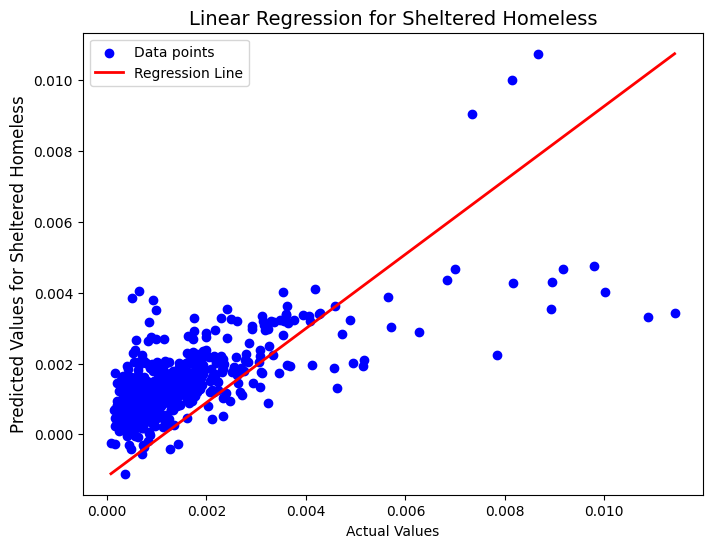

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

best_target = 'Sheltered_Homeless_Per_Capita'

X_best = x_test[['Total Population',
    'Median Gross Rent',
    'Median Household Income',
    'Poverty_Rate',
    'Vacancy_Rate',
    'Unemployment_Rate',
    'Cost_Burdened_Rate',
    'Renter_Household_Rate',
    'Total Year-Round Beds (ES, TH, SH)',
    'Average Temperature',
    'Poverty_Unemployment_Interaction',
    'Rent Burden',
    'Vacancy_Renter_Interaction']]

y_best = y_test[best_target]

model = LinearRegression()
model.fit(X_best, y_best)

y_pred_best = model.predict(X_best)

plt.figure(figsize=(8, 6))
plt.scatter(y_best, y_pred_best, color='blue', label='Data points')
plt.plot([min(y_best), max(y_best)], [min(y_pred_best), max(y_pred_best)], color='red', linewidth=2, label='Regression Line')

plt.title(f"Linear Regression for Sheltered Homeless", fontsize=14)
plt.xlabel('Actual Values')
plt.ylabel(f'Predicted Values for Sheltered Homeless', fontsize=12)
plt.legend()

plt.show()
